# Survey Analysis: Academic Writing Workflows, AI Tools, and Citation Integrity

This notebook analyzes combined survey data from:
- **English Survey**: 18 individual responses (raw data)
- **Chinese Survey**: 79 respondents (aggregated statistics)

**Total Combined**: 97 respondents


In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Create output directory
os.makedirs('figs', exist_ok=True)

# Set plot style for academic publication (matching existing project style)
sns.set_theme(style="ticks", context="paper", font_scale=1.0)
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("viridis")

# Academic formatting
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'figure.dpi': 150,
    'figure.constrained_layout.use': True,  # Better spacing
})

print("Setup complete.")

Setup complete.


## 1. Parse Chinese Survey Data (Aggregated Statistics)

In [120]:
# Parse Chinese survey from markdown format
with open('chinese.md', 'r', encoding='utf-8') as f:
    cn_content = f.read()

# Split by questions (第X题)
question_pattern = r'第(\d+)题\s+(.+?)\s+\[([单多]选题|填空题)\]'
questions = re.findall(question_pattern, cn_content)

print(f"Found {len(questions)} questions in Chinese survey")
for q_num, q_text, q_type in questions[:5]:
    print(f"  Q{q_num}: {q_text[:50]}... [{q_type}]")

Found 43 questions in Chinese survey
  Q1: 点击下方的“是”即表示您确认以下事项：1. 您了解本次参与是完全自愿的。2. 您了解您可以随时中止作... [单选题]
  Q2: 您目前的学术职位是?... [单选题]
  Q3: 您的主要研究领域是?... [单选题]
  Q4: 您职业生涯中发表了多少篇同行评审论文?... [单选题]
  Q5: 英语是否为您的母语?... [单选题]


In [121]:
# Parse each question's options and counts
cn_data = {}

# Split content by questions
sections = re.split(r'第\d+题', cn_content)

for i, (q_num, q_text, q_type) in enumerate(questions):
    section = sections[i+1] if i+1 < len(sections) else ""
    
    # Find table data: lines with "选项\t小计\t比例" pattern
    lines = section.strip().split('\n')
    options = {}
    
    in_table = False
    for line in lines:
        if '选项' in line and '小计' in line:
            in_table = True
            continue
        if '本题有效填写人次' in line:
            in_table = False
            continue
        if in_table and '\t' in line:
            parts = line.split('\t')
            if len(parts) >= 2:
                option = parts[0].strip()
                try:
                    count = int(parts[1].strip())
                    options[option] = count
                except:
                    pass
    
    cn_data[int(q_num)] = {
        'text': q_text.strip(),
        'type': q_type,
        'options': options
    }

print(f"\nParsed {len(cn_data)} questions with options")
# Show sample
for q_num in [2, 9, 13, 30]:
    if q_num in cn_data:
        print(f"\nQ{q_num}: {cn_data[q_num]['text'][:40]}...")
        for opt, cnt in list(cn_data[q_num]['options'].items())[:3]:
            print(f"  - {opt}: {cnt}")


Parsed 43 questions with options

Q2: 您目前的学术职位是?...
  - 本科生: 14
  - 硕士生: 18
  - 博士生: 26

Q9: 您是否使用AI工具进行研究？...
  - 是: 69
  - 否: 10

Q13: 当使用通用 LLM（如 ChatGPT）寻找参考文献时，您遇到“幻觉”（不存在的...
  - 非常频繁（&gt;50% 的时间）: 7
  - 经常（20-50%）: 24
  - 偶尔（&lt;20%）: 15

Q30: 在 AI 时代，您认为“幻觉引用”（不存在的论文）是一个多严重的问题?...
  - 严重危机: 34
  - 主要问题: 24
  - 轻微干扰: 20


## 2. Parse English Survey Data (Individual Responses)

In [122]:
# Load English CSV
df_en = pd.read_csv('Survey on Academic Writing Workflows, AI Tools, and Citation Integrity.csv')
n_en = len(df_en)
print(f"English survey: {n_en} responses")
print(f"Columns: {len(df_en.columns)}")

English survey: 18 responses
Columns: 59


In [123]:
# Define English column indices for key questions
# Based on CSV structure analysis

en_columns = {
    'position': 2,  # Academic position
    'research_area': 3,  # Research area
    'papers_published': 4,  # Papers published
    'native_english': 5,  # Native English
    'is_reviewer': 6,  # Served as reviewer
}

# For reviewers (columns after index 35)
# For non-reviewers (columns 7-21)
# Common questions for all (later columns)

# Extract counts from English data
def count_english_responses(df, col_idx, col_idx2=None):
    """Count responses from one or two columns (for branching questions)"""
    counts = {}
    
    # Primary column
    if col_idx < len(df.columns):
        vals = df.iloc[:, col_idx].dropna()
        for val in vals:
            if str(val).strip():
                # Handle multi-select (semicolon separated)
                for v in str(val).split(';'):
                    v = v.strip()
                    if v:
                        counts[v] = counts.get(v, 0) + 1
    
    # Secondary column (for branching)
    if col_idx2 and col_idx2 < len(df.columns):
        vals = df.iloc[:, col_idx2].dropna()
        for val in vals:
            if str(val).strip():
                for v in str(val).split(';'):
                    v = v.strip()
                    if v:
                        counts[v] = counts.get(v, 0) + 1
    
    return counts

# Test
position_counts_en = count_english_responses(df_en, 2)
print("English Position Distribution:")
for k, v in position_counts_en.items():
    print(f"  {k}: {v}")

English Position Distribution:
  Faculty (Professor/Lecturer): 3
  Researcher: 3
  Other: 2
  Undergraduate student: 1
  PhD Student: 7
  Master's Student: 1
  Postdoc: 1


## 3. Define Chinese-English Option Mapping

In [124]:
# Comprehensive mapping from Chinese to English options
cn_to_en = {
    # Position (Q2)
    '本科生': 'Undergraduate student',
    '硕士生': "Master's Student",
    '博士生': 'PhD Student',
    '博士后': 'Postdoc',
    '教职人员（教授/讲师）': 'Faculty (Professor/Lecturer)',
    '研究员': 'Researcher',
    '其他': 'Other',
    
    # Research Area (Q3)
    'AI安全': 'AI Security',
    '网络安全': 'Network Security',
    '系统安全': 'System Security',
    '密码学': 'Cryptography',
    '软件工程': 'Software Engineering',
    '人工智能与机器学习': 'AI & Machine Learning',
    
    # Papers Published (Q4)
    '0': '0',
    '1-5': '1-5',
    '6-10': '6-10',
    '11-20': '11-20',
    '20+': '20+',
    
    # Yes/No
    '是': 'Yes',
    '否': 'No',
    '是，我同意参与调查': 'Yes, I consent to participate.',
    '否，我不同意': 'No',
    
    # AI Tool Usage (Q9)
    # Already mapped above
    
    # AI Tool Types (Q10)
    '通用大语言模型（如 ChatGPT, Claude, Gemini）': 'General-purpose LLMs (e.g., ChatGPT, Claude, Gemini)',
    '代码助手（如 GitHub Copilot, Cursor）': 'Coding Assistants (e.g., GitHub Copilot, Cursor)',
    '学术专用搜索引擎（如 Elicit, Consensus, Scite, Semantic Scholar）': 'Academic search engines (e.g., Elicit, Semantic Scholar)',
    'AI 驱动的阅读/笔记工具（如 ChatPDF, Humata）': 'AI-powered reading tools (e.g., ChatPDF, Humata)',
    
    # Text polishing (Q11)
    '是，几乎每一句都用': 'Yes, for almost every sentence',
    '是，仅针对特定的困难段落': 'Yes, for specific difficult paragraphs',
    '是，但仅用于最后的校对': 'Yes, but only for final proofreading',
    '否，我更相信自己的写作': 'No, I trust my own writing more',
    
    # Citation AI usage (Q12)
    '格式转换:将参考文献转换为特定格式，比如 BibTeX': 'Formatting',
    '发现:要求 AI 推荐特定主题的论文': 'Discovery',
    '填补空白:"我需要为这句话找一个引用，请帮我找一个。"': 'Gap-filling',
    '摘要:要求 AI 总结论文以决定是否引用': 'Summarization',
    '验证:询问 AI 某篇论文是否存在': 'Verification',
    '不使用:不在引用部分使用AI工具': 'None',
    
    # Hallucination frequency (Q13)
    '非常频繁（>50% 的时间）': 'Very Often (>50%)',
    '经常（20-50%）': 'Often (20-50%)',
    '偶尔（<20%）': 'Occasionally (<20%)',
    '从未': 'Never',
    '我不用通用 LLM 找参考文献': "Don't use LLMs",
    
    # Verification (Q14)
    '是，我会通过谷歌学术/DBLP 100% 验证': 'Always verify (100%)',
    '我只在需要阅读全文时才验证': 'Only if reading full text',
    '我只在标题看起来可疑时验证': 'Only if suspicious',
    '否，如果元数据连贯，我信任该工具': 'Trust AI',
    
    # Cited without reading (Q15)
    '是，经常': 'Yes, often',
    '是，一两次': 'Yes, once or twice',
    '否，从不': 'No, never',
    
    # Agreement scale
    '非常同意': 'Strongly agree',
    '有点同意': 'Somewhat agree',
    '中立': 'Neutral',
    '有点不同意': 'Somewhat disagree',
    '非常不同意': 'Strongly disagree',
    
    # Broken DOI strategy (Q17)
    '我假设论文存在并尝试手动查找': 'Try to find manually',
    '我假设论文是幻觉并立即舍弃': 'Assume hallucination, discard',
    '我要求 AI 提供另一个链接': 'Ask AI for another link',
    '我保留引用但删除 DOI': 'Keep citation, remove DOI',
    
    # Metadata source (Q18)
    '直接从出版商导出': 'Direct export from publisher',
    '谷歌学术的"引用"按钮': 'Google Scholar "Cite" button',
    '复制粘贴自其他论文的参考文献列表': 'Copy from other papers',
    '由 AI 工具生成': 'AI-generated',
    
    # Verify claim frequency (Q19)
    '每次都会': 'Every single time',
    '大部分时间': 'Most of the time',
    '仅针对关键观点': 'Only for critical claims',
    '很少': 'Rarely',
    
    # Cite without full text (Q20)
    '是，如果有必要': 'Yes, if necessary',
    
    # Reviewer check refs (Q22)
    '是，仔细检查': 'Yes, carefully',
    '是，略读': 'Yes, skimming',
    
    # What reviewers check (Q23)
    '自引滥用': 'Self-citation abuse',
    '遗漏关键相关工作': 'Missing key related work',
    '元数据的正确性（年份、会议）': 'Correctness of metadata',
    '论文是否存在': 'Existence of papers',
    
    # Click DOI frequency (Q24)
    '经常': 'Frequently',
    '偶尔': 'Occasionally',
    '很少': 'Rarely',
    '从未': 'Never',
    
    # Verify preprint (Q26)
    '总是': 'Always',
    '有时': 'Sometimes',
    
    # Handle non-English (Q27)
    '我用翻译工具检查': 'Check with translation tools',
    '我忽略它们': 'Ignore them',
    '我要求作者澄清': 'Ask authors to clarify',
    '我假设它们是有效的': 'Assume they are valid',
    
    # Peer review effectiveness (Q29)
    '非常有效': 'Very effective',
    '比较有效': 'Somewhat effective',
    '不太有效': 'Not very effective',
    '无效': 'Ineffective',
    
    # Severity (Q30)
    '严重危机': 'Critical crisis',
    '主要问题': 'Major problem',
    '轻微干扰': 'Minor nuisance',
    '不是问题': 'Not a problem',
    
    # Responsibility (Q31)
    '作者': 'Authors',
    '审稿人': 'Reviewers',
    '出版商（编辑检查）': 'Publishers',
    'AI 工具开发者': 'AI tool developers',
    
    # Automated tools (Q32)
    '是，绝对应该': 'Yes, absolutely',
    '也许': 'Maybe',
    '否，负担太重': 'No',
    
    # Reaction to one error (Q37)
    '拒稿': 'Reject the paper',
    '要求大修': 'Ask for major revision',
    '在次要意见中提及': 'Mention in minor comments',
    '忽略': 'Ignore',
    
    # Reaction to multiple errors (Q38)
    '立即拒稿（伦理问题）': 'Reject immediately (Ethical concern)',
    '要求解释': 'Ask for explanation',
    '认为是无心之失': 'Consider innocent mistake',
    
    # Copy-paste BibTeX (Q40)
    '是，很少': 'Yes, rarely',
    '否，从未': 'No, never',  # Variant of 否，从不
    
    # Report fake reference (Q39) - missing mappings
    '是，我会直接联系作者': 'Yes, I would contact the authors directly',
    '是，我会联系程序委员会主席或期刊编辑': 'Yes, I would contact the PC Chairs or Journal Editors',
    '否，我会私下验证但不采取行动': 'No, I would verify it privately but take no action',
    '否，我会忽略它': 'No, I would ignore it',
}

import html

def normalize_option(option):
    """Normalize Chinese option text by decoding HTML entities and normalizing quotes"""
    if not isinstance(option, str):
        return option
    # Decode HTML entities like &gt; -> > and &lt; -> <
    option = html.unescape(option)
    # Normalize Chinese quotes to ASCII quotes (U+201C, U+201D -> U+0022)
    option = option.replace('\u201c', '"').replace('\u201d', '"')
    # Normalize Chinese single quotes (U+2018, U+2019 -> U+0027)
    option = option.replace('\u2018', "'").replace('\u2019', "'")
    return option

def translate_cn_to_en(option):
    """Translate Chinese option to English"""
    normalized = normalize_option(option)
    return cn_to_en.get(normalized, cn_to_en.get(option, option))

print(f"Defined {len(cn_to_en)} translation mappings")

Defined 108 translation mappings


## 4. Merge Chinese and English Statistics

In [125]:
# Define question mapping between Chinese (by number) and English (by column index)
# CN Q# -> EN column index (or list of indices for branching)

question_mapping = {
    # Demographics
    2: {'en_col': 2, 'name': 'position'},
    3: {'en_col': 3, 'name': 'research_area'},
    4: {'en_col': 4, 'name': 'papers_published'},
    5: {'en_col': 5, 'name': 'native_english'},
    6: {'en_col': 6, 'name': 'is_reviewer'},
    
    # AI Usage
    9: {'en_col': [9, 23], 'name': 'use_ai_tools'},
    10: {'en_col': [10, 24], 'name': 'ai_tool_types'},
    11: {'en_col': [11, 25], 'name': 'ai_text_polish'},
    12: {'en_col': [12, 26], 'name': 'ai_citation_usage'},
    13: {'en_col': [13, 27], 'name': 'hallucination_freq'},
    14: {'en_col': [14, 28], 'name': 'verify_ai_ref'},
    15: {'en_col': [15, 29], 'name': 'cite_without_reading'},
    16: {'en_col': [16, 30], 'name': 'agree_ai_easier_harder'},
    17: {'en_col': [17, 31], 'name': 'broken_doi_strategy'},
    
    # Citation practices (all respondents)
    18: {'en_col': [18, 32], 'name': 'metadata_source'},
    19: {'en_col': [19, 33], 'name': 'verify_claim_freq'},
    20: {'en_col': [20, 34], 'name': 'cite_without_fulltext'},
    21: {'en_col': [21, 35], 'name': 'pressure_many_refs'},
    
    # Reviewer perspective (only reviewers)
    22: {'en_col': 36, 'name': 'reviewer_check_refs'},
    23: {'en_col': 37, 'name': 'what_reviewers_check'},
    24: {'en_col': 38, 'name': 'click_doi_verify'},
    25: {'en_col': 39, 'name': 'suspected_fake'},
    26: {'en_col': 40, 'name': 'verify_preprint'},
    27: {'en_col': 41, 'name': 'handle_non_english'},
    
    # Integrity perception (all)
    28: {'en_col': 42, 'name': 'agree_bib_accuracy'},
    29: {'en_col': 43, 'name': 'peer_review_effective'},
    30: {'en_col': 44, 'name': 'severity'},
    31: {'en_col': 45, 'name': 'responsibility'},
    32: {'en_col': 46, 'name': 'automated_tools'},
    33: {'en_col': 47, 'name': 'agree_cite_ai_summary'},
    
    # Edge cases
    34: {'en_col': 49, 'name': 'seen_scrambled_authors'},
    35: {'en_col': 50, 'name': 'seen_wrong_venue_year'},
    36: {'en_col': 51, 'name': 'accept_tech_report'},
    37: {'en_col': 52, 'name': 'reaction_one_error'},
    38: {'en_col': 53, 'name': 'reaction_multiple_errors'},
    39: {'en_col': 54, 'name': 'report_fake_ref'},
    40: {'en_col': 48, 'name': 'copypaste_bibtex'},
    41: {'en_col': 55, 'name': 'verify_all_bibtex_fields'},
    42: {'en_col': 56, 'name': 'use_semantic_scholar'},
}

print(f"Mapped {len(question_mapping)} questions")

Mapped 39 questions


In [126]:
# Function to merge counts
def merge_counts(cn_opts, en_counts):
    """Merge Chinese (translated) and English counts"""
    merged = {}
    
    # Add Chinese counts (translated)
    for cn_opt, count in cn_opts.items():
        en_opt = translate_cn_to_en(cn_opt)
        merged[en_opt] = merged.get(en_opt, 0) + count
    
    # Add English counts
    for en_opt, count in en_counts.items():
        # Try to match with existing keys (handle slight variations)
        matched = False
        for key in merged:
            if key.lower() in en_opt.lower() or en_opt.lower() in key.lower():
                merged[key] += count
                matched = True
                break
        if not matched:
            merged[en_opt] = merged.get(en_opt, 0) + count
    
    return merged

# Build combined statistics
combined_stats = {}

for cn_q, mapping in question_mapping.items():
    if cn_q not in cn_data:
        continue
    
    cn_opts = cn_data[cn_q]['options']
    
    # Get English counts
    en_cols = mapping['en_col']
    if isinstance(en_cols, list):
        en_counts = count_english_responses(df_en, en_cols[0], en_cols[1] if len(en_cols) > 1 else None)
    else:
        en_counts = count_english_responses(df_en, en_cols)
    
    # Merge
    merged = merge_counts(cn_opts, en_counts)
    
    combined_stats[mapping['name']] = {
        'cn_text': cn_data[cn_q]['text'],
        'counts': merged,
        'cn_n': sum(cn_opts.values()),
        'en_n': sum(en_counts.values())
    }

print(f"Built combined statistics for {len(combined_stats)} questions")

Built combined statistics for 39 questions


In [127]:
# Display sample combined statistics
for name in ['position', 'use_ai_tools', 'hallucination_freq', 'severity']:
    if name in combined_stats:
        print(f"\n=== {name} ===")
        print(f"CN: {combined_stats[name]['cn_n']}, EN: {combined_stats[name]['en_n']}")
        for opt, cnt in sorted(combined_stats[name]['counts'].items(), key=lambda x: -x[1]):
            print(f"  {opt}: {cnt}")


=== position ===
CN: 79, EN: 18
  PhD Student: 33
  Master's Student: 19
  Faculty (Professor/Lecturer): 17
  Undergraduate student: 15
  Postdoc: 6
  Researcher: 5
  Other: 2

=== use_ai_tools ===
CN: 79, EN: 18
  Yes: 74
  No: 13
  Following citations from other papers: 4
  Keyword search on Google Scholar/DBLP: 3
  Browsing conference proceedings: 2
  Using AI-powered tools (e.g., ChatGPT, Connected Papers): 1

=== hallucination_freq ===
CN: 69, EN: 14
  Often (20-50%): 25
  Don't use LLMs: 19
  Occasionally (<20%): 15
  Very Often (>50%): 7
  Never: 4
  Discovery: Asking AI to recommend papers on a specific topic: 4
  Formatting: Converting references into specific formats (e.g., BibTeX): 3
  I do not use General LLMs for finding references: 2
  Very Often (>50% of the time): 2
  Summarization: Asking AI to summarize a paper to decide whether to cite it: 1
  Verification: Asking AI if a specific paper exists: 1

=== severity ===
CN: 79, EN: 18
  Critical crisis: 34
  Major problem

## 5. Demographics Visualization


All 4 demographic pie charts saved to figs/


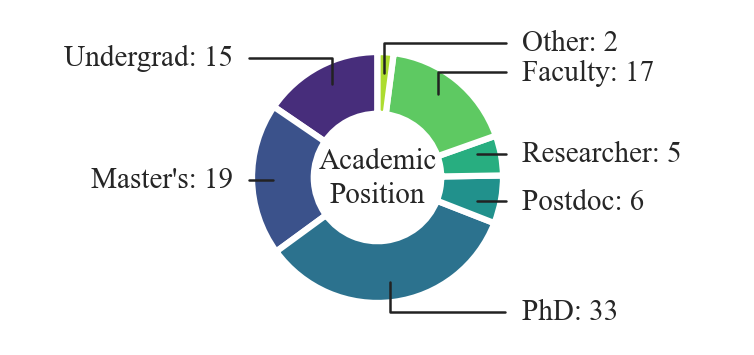

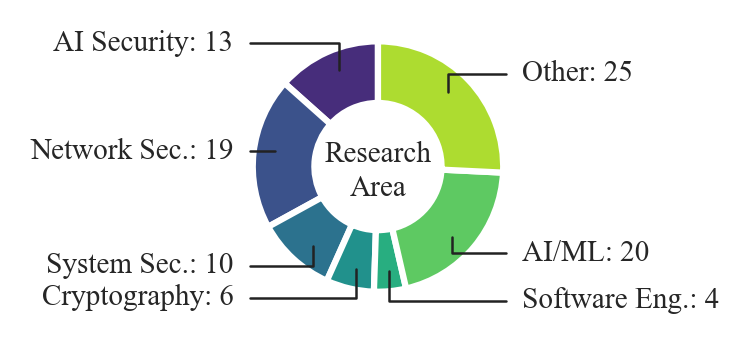

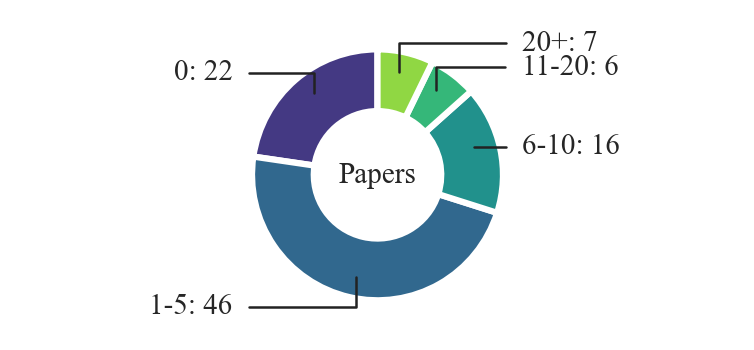

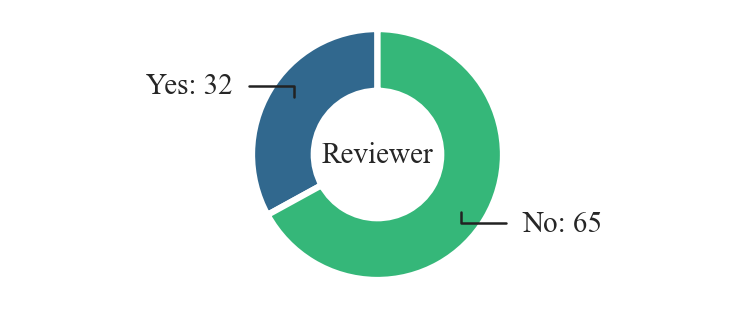

In [128]:
# USENIX Security Style - 4 Separate Demographic Pie Charts

def setup_usenix_style():
    """Setup USENIX Security conference style"""
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
        'font.size': 8,
        'axes.titlesize': 9,
        'axes.labelsize': 8,
        'legend.fontsize': 7,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'axes.linewidth': 0.5,
    })

def plot_donut_usenix(data, title, filename, figsize=(2.4, 2.4)):
    """Create a donut chart with line annotations in USENIX style"""
    setup_usenix_style()
    fig, ax = plt.subplots(figsize=figsize)
    
    # Filter out zero values
    filtered_data = {k: v for k, v in data.items() if v > 0}
    colors = sns.color_palette("viridis", len(filtered_data))
    
    radius = 1.3

    # Create donut chart
    wedges, _ = ax.pie(
        filtered_data.values(), 
        colors=colors,
        startangle=90,
        radius = radius,
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white', 'width': 0.64}
    )

    # 增大坐标轴范围，给标签留空间
    limit = 3.6  # 关键：增大这个值
    ax.set_xlim(-limit, limit)
    
    # Add line annotations with labels and counts
    for i, (wedge, (label, count)) in enumerate(zip(wedges, filtered_data.items())):
        ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
        if label == "Software Eng.":
            ang += 1
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))
        
        # Annotation position - horizontal extension
        x_text = 1.5 if x >= 0 else -1.5
        y_ann = 1.4 * y
        ha = 'left' if x >= 0 else 'right'
        
        # Draw straight lines: from wedge -> elbow -> text
        ax.annotate(
            f'{label}: {count}',
            xy=(x, y),
            xytext=(x_text, y_ann),
            fontsize=7,
            ha=ha, va='center',
            arrowprops=dict(arrowstyle='-', color='#222222', lw=0.6,
                           connectionstyle='angle,angleA=0,angleB=90,rad=0')
        )
    
    # Add center label (title in the donut hole)
    total = sum(filtered_data.values())
    if title == "Research\nArea":
        ax.text(0, -0.05, f'{title}', ha='center', va='center', 
            fontsize=7, linespacing=1.3)
    else: 
        ax.text(0, 0, f'{title}', ha='center', va='center', 
            fontsize=7, linespacing=1.3)
       # 手动调整子图边距
    
    plt.savefig(f'figs/{filename}', dpi=300, bbox_inches='tight', pad_inches=0)

# Alias for compatibility
plot_pie_usenix = plot_donut_usenix

# (1) Academic Position
data = combined_stats['position']['counts']
label_map = {'Undergraduate student': 'Undergrad', "Master's Student": "Master's", 
             'PhD Student': 'PhD', 'Postdoc': 'Postdoc', 'Researcher': 'Researcher',
             'Faculty (Professor/Lecturer)': 'Faculty', 'Other': 'Other'}
order = ['Undergraduate student', "Master's Student", 'PhD Student', 'Postdoc', 
         'Researcher', 'Faculty (Professor/Lecturer)', 'Other']
ordered_data = {}
for k in order:
    if k in data:
        ordered_data[label_map.get(k, k[:12])] = data[k]
for k in data:
    short_k = label_map.get(k, k[:12])
    if short_k not in ordered_data:
        ordered_data[short_k] = data[k]
plot_pie_usenix(ordered_data, 'Academic\nPosition', 'demo_position.pdf')

# (2) Research Area
data = combined_stats['research_area']['counts']
short_map = {'AI & Machine Learning': 'AI/ML', 'AI Security': 'AI Security',
             'Network Security': 'Network Sec.', 'System Security': 'System Sec.',
             'Software Engineering': 'Software Eng.', 'Cryptography': 'Cryptography'}
short_data = {short_map.get(k, k[:15]): v for k, v in data.items()}
plot_pie_usenix(short_data, 'Research\nArea', 'demo_research_area.pdf')

# (3) Papers Published
data = combined_stats['papers_published']['counts']
order = ['0', '1-5', '6-10', '11-20', '20+']
ordered_data = {k: data.get(k, 0) for k in order if data.get(k, 0) > 0}
plot_pie_usenix(ordered_data, 'Papers', 'demo_papers.pdf')

# (4) Reviewer Status
data = combined_stats['is_reviewer']['counts']
plot_pie_usenix(data, 'Reviewer', 'demo_reviewer.pdf')

print("\nAll 4 demographic pie charts saved to figs/")

## 6. AI Tool Usage Analysis

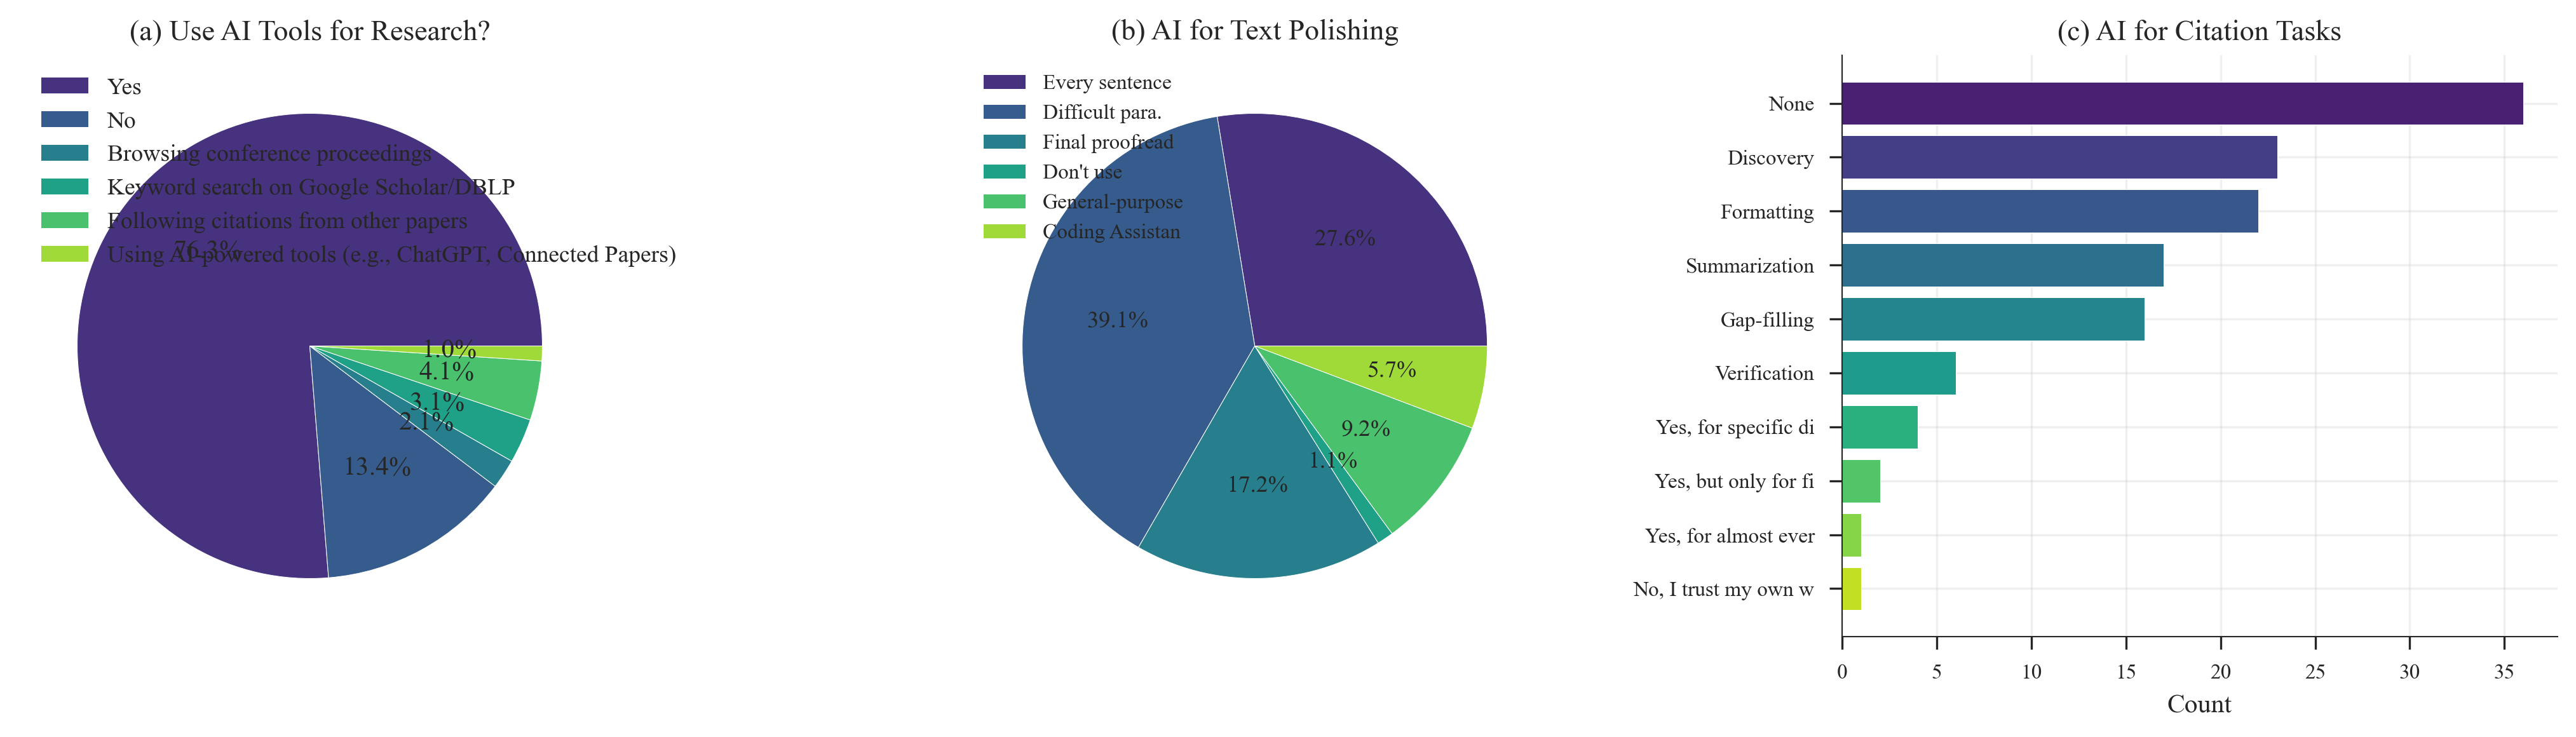

Saved: figs/ai_tool_usage.pdf


In [129]:
# Figure 2: AI Tool Usage
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Use AI Tools? - use legend
ax = axes[0]
data = combined_stats['use_ai_tools']['counts']
colors = sns.color_palette("viridis", len(data))
wedges, texts, autotexts = ax.pie(data.values(), autopct='%1.1f%%', colors=colors,
                                   textprops={'fontsize': 10}, pctdistance=0.6)
ax.legend(wedges, data.keys(), loc='upper left', fontsize=9, frameon=False)
ax.set_title('(a) Use AI Tools for Research?', fontsize=11)

# (b) AI for Text Polishing - use legend
ax = axes[1]
if 'ai_text_polish' in combined_stats:
    data = combined_stats['ai_text_polish']['counts']
    # Shorten labels
    short_labels = {
        'Yes, for almost every sentence': 'Every sentence',
        'Yes, for specific difficult paragraphs': 'Difficult para.',
        'Yes, but only for final proofreading': 'Final proofread',
        'No, I trust my own writing more': "Don't use",
    }
    data_short = {short_labels.get(k, k[:15]): v for k, v in data.items()}
    colors = sns.color_palette("viridis", len(data_short))
    wedges, texts, autotexts = ax.pie(data_short.values(), autopct='%1.1f%%', colors=colors,
                                       textprops={'fontsize': 9}, pctdistance=0.6)
    ax.legend(wedges, data_short.keys(), loc='upper left', fontsize=8, frameon=False)
ax.set_title('(b) AI for Text Polishing', fontsize=11)

# (c) AI for Citations - shorten labels
ax = axes[2]
if 'ai_citation_usage' in combined_stats:
    data = combined_stats['ai_citation_usage']['counts']
    sorted_data = dict(sorted(data.items(), key=lambda x: -x[1]))
    short_data = {k[:20]: v for k, v in sorted_data.items()}
    colors = sns.color_palette("viridis", len(short_data))
    bars = ax.barh(list(short_data.keys()), list(short_data.values()), color=colors)
    ax.set_xlabel('Count', fontsize=10)
    ax.set_title('(c) AI for Citation Tasks', fontsize=11)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout(pad=1.5)
plt.savefig('figs/ai_tool_usage.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figs/ai_tool_usage.pdf")

## 7. Hallucination Experience & Verification

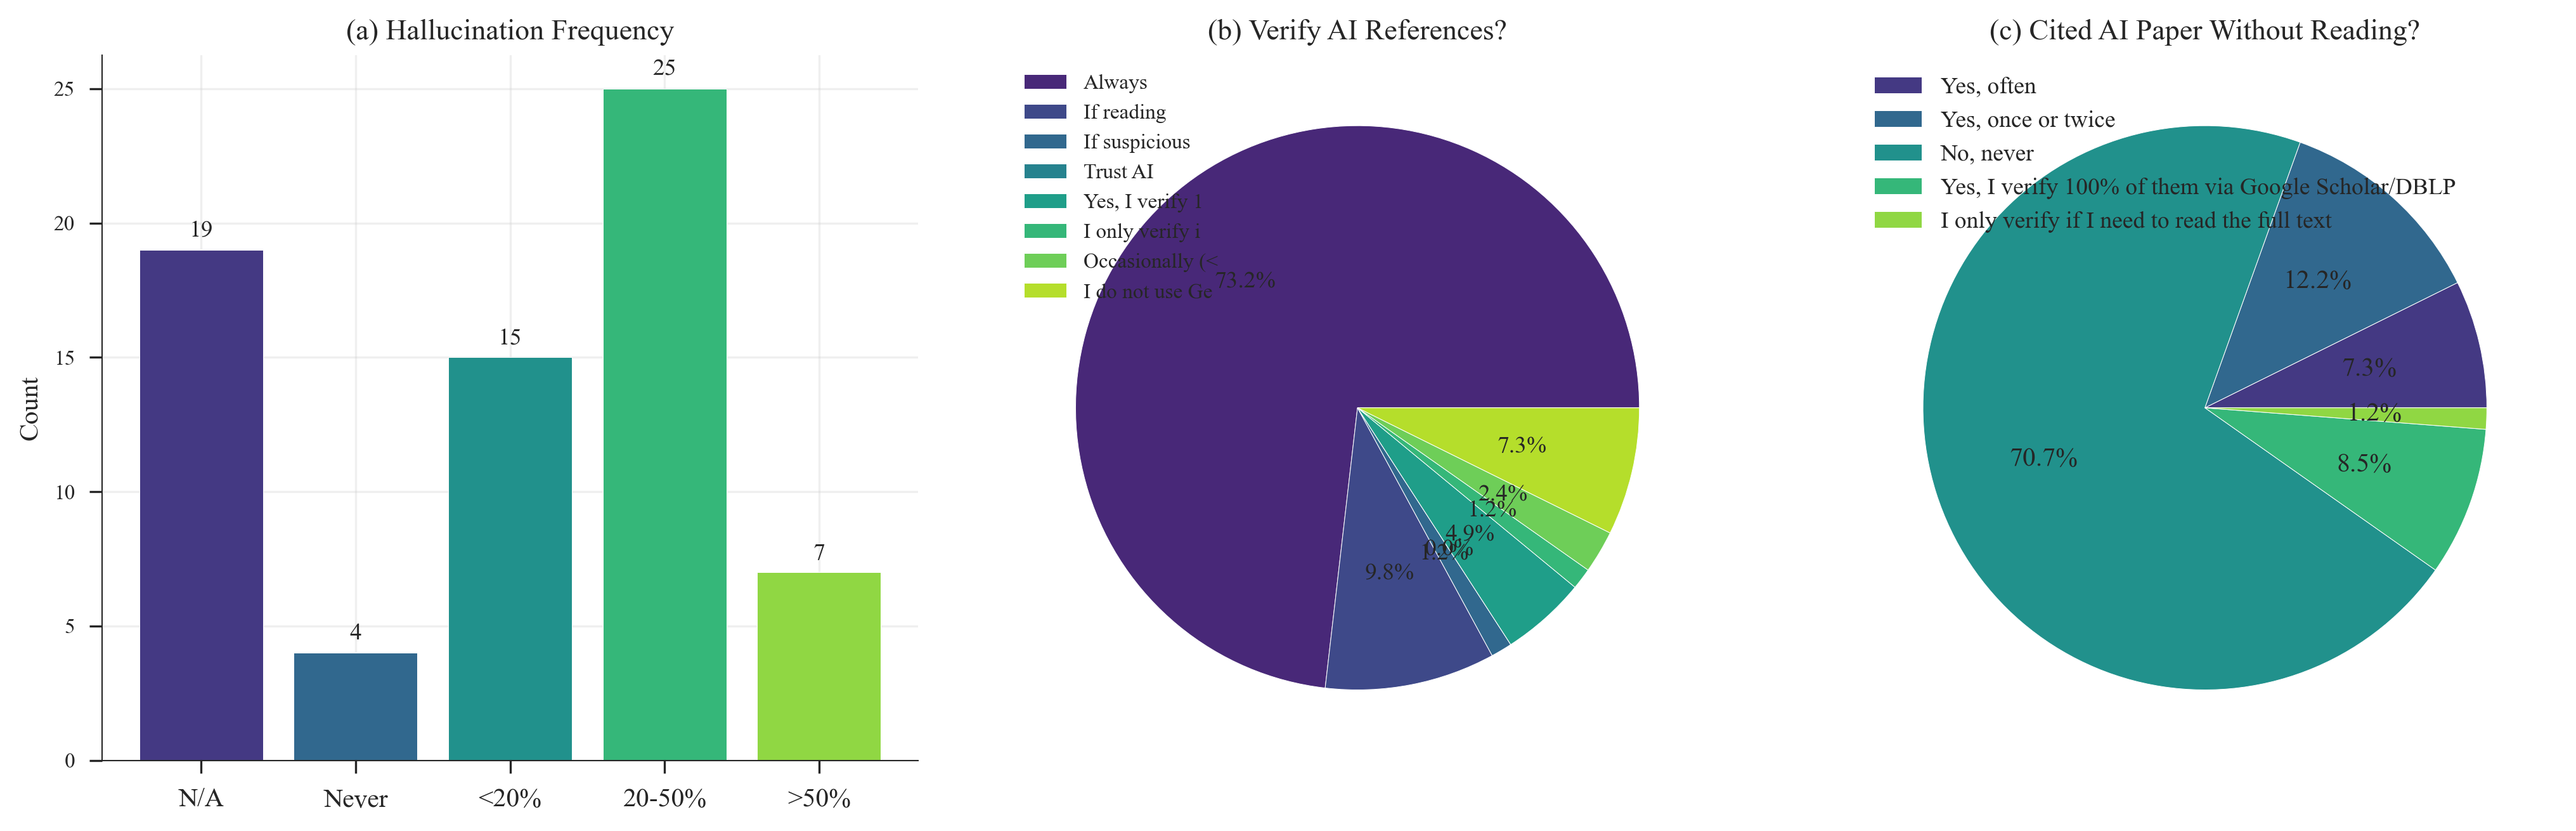

Saved: figs/hallucination_verification.pdf


In [130]:
# Figure 3: Hallucination & Verification
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# (a) Hallucination Frequency - shorter labels
ax = axes[0]
if 'hallucination_freq' in combined_stats:
    data = combined_stats['hallucination_freq']['counts']
    # Desired order with short labels
    order_map = {"Don't use LLMs": "N/A", 'Never': 'Never', 'Occasionally (<20%)': '<20%', 
                 'Often (20-50%)': '20-50%', 'Very Often (>50%)': '>50%'}
    ordered = {}
    for o, short in order_map.items():
        for k, v in data.items():
            if o.lower() in k.lower() or k.lower() in o.lower():
                ordered[short] = v
                break
    
    colors = sns.color_palette("viridis", len(ordered))
    bars = ax.bar(range(len(ordered)), list(ordered.values()), color=colors)
    ax.set_xticks(range(len(ordered)))
    ax.set_xticklabels(list(ordered.keys()), rotation=0, ha='center', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('(a) Hallucination Frequency', fontsize=11)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{int(h)}', ha='center', fontsize=9)

# (b) Verification Behavior - use legend
ax = axes[1]
if 'verify_ai_ref' in combined_stats:
    data = combined_stats['verify_ai_ref']['counts']
    short_labels = {
        'Always verify (100%)': 'Always',
        'Only if reading full text': 'If reading',
        'Only if suspicious': 'If suspicious',
        'Trust AI': 'Trust AI',
    }
    data_short = {}
    for k, v in data.items():
        for sk, sv in short_labels.items():
            if sk.lower() in k.lower() or k.lower() in sk.lower():
                data_short[sv] = v
                break
        else:
            data_short[k[:15]] = v
    colors = sns.color_palette("viridis", len(data_short))
    wedges, texts, autotexts = ax.pie(data_short.values(), autopct='%1.1f%%', colors=colors,
                                       textprops={'fontsize': 9}, pctdistance=0.6)
    ax.legend(wedges, data_short.keys(), loc='upper left', fontsize=8, frameon=False)
ax.set_title('(b) Verify AI References?', fontsize=11)

# (c) Cited Without Reading - use legend
ax = axes[2]
if 'cite_without_reading' in combined_stats:
    data = combined_stats['cite_without_reading']['counts']
    colors = sns.color_palette("viridis", len(data))
    wedges, texts, autotexts = ax.pie(data.values(), autopct='%1.1f%%', colors=colors,
                                       textprops={'fontsize': 10}, pctdistance=0.6)
    ax.legend(wedges, data.keys(), loc='upper left', fontsize=9, frameon=False)
ax.set_title('(c) Cited AI Paper Without Reading?', fontsize=11)

plt.tight_layout(pad=1.5)
plt.savefig('figs/hallucination_verification.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figs/hallucination_verification.pdf")

## 8. Severity & Responsibility Perception

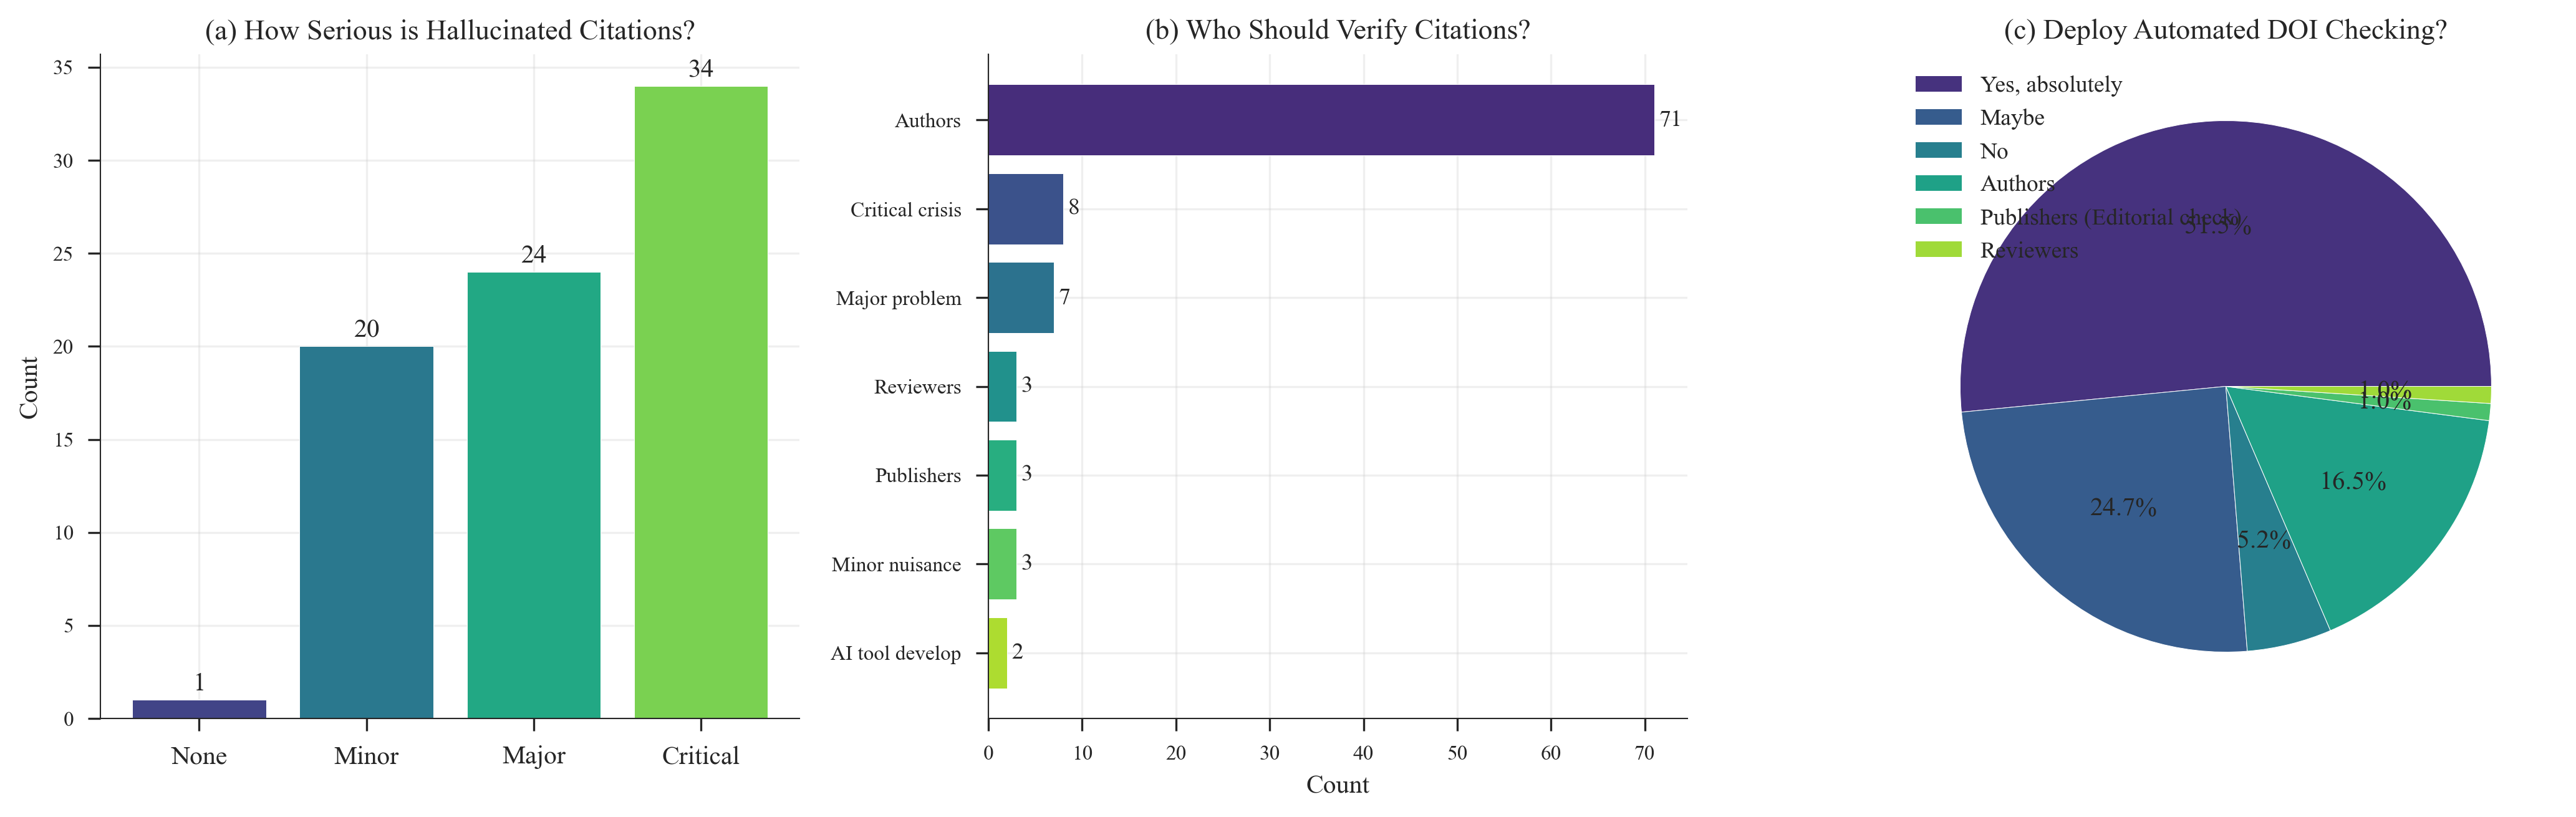

Saved: figs/severity_responsibility.pdf


In [131]:
# Figure 4: Severity & Responsibility
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# (a) Severity Perception - shorter labels
ax = axes[0]
if 'severity' in combined_stats:
    data = combined_stats['severity']['counts']
    order_map = {'Not a problem': 'None', 'Minor nuisance': 'Minor', 
                 'Major problem': 'Major', 'Critical crisis': 'Critical'}
    ordered = {order_map[o]: data.get(o, 0) for o in order_map if o in data or data.get(o, 0) > 0}
    colors = sns.color_palette("viridis", len(ordered))
    bars = ax.bar(ordered.keys(), ordered.values(), color=colors)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('(a) How Serious is Hallucinated Citations?', fontsize=11)
    ax.tick_params(axis='x', labelsize=10)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{int(h)}', ha='center', fontsize=10)

# (b) Responsibility - shorter labels
ax = axes[1]
if 'responsibility' in combined_stats:
    data = combined_stats['responsibility']['counts']
    sorted_data = dict(sorted(data.items(), key=lambda x: -x[1]))
    short_data = {k[:15]: v for k, v in sorted_data.items()}
    colors = sns.color_palette("viridis", len(short_data))
    bars = ax.barh(list(short_data.keys()), list(short_data.values()), color=colors)
    ax.set_xlabel('Count', fontsize=10)
    ax.set_title('(b) Who Should Verify Citations?', fontsize=11)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, short_data.values()):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

# (c) Automated Tools Support - use legend
ax = axes[2]
if 'automated_tools' in combined_stats:
    data = combined_stats['automated_tools']['counts']
    colors = sns.color_palette("viridis", len(data))
    wedges, texts, autotexts = ax.pie(data.values(), autopct='%1.1f%%', colors=colors,
                                       textprops={'fontsize': 10}, pctdistance=0.6)
    ax.legend(wedges, data.keys(), loc='upper left', fontsize=9, frameon=False)
ax.set_title('(c) Deploy Automated DOI Checking?', fontsize=11)

plt.tight_layout(pad=1.5)
plt.savefig('figs/severity_responsibility.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figs/severity_responsibility.pdf")

## 9. Citation Practices

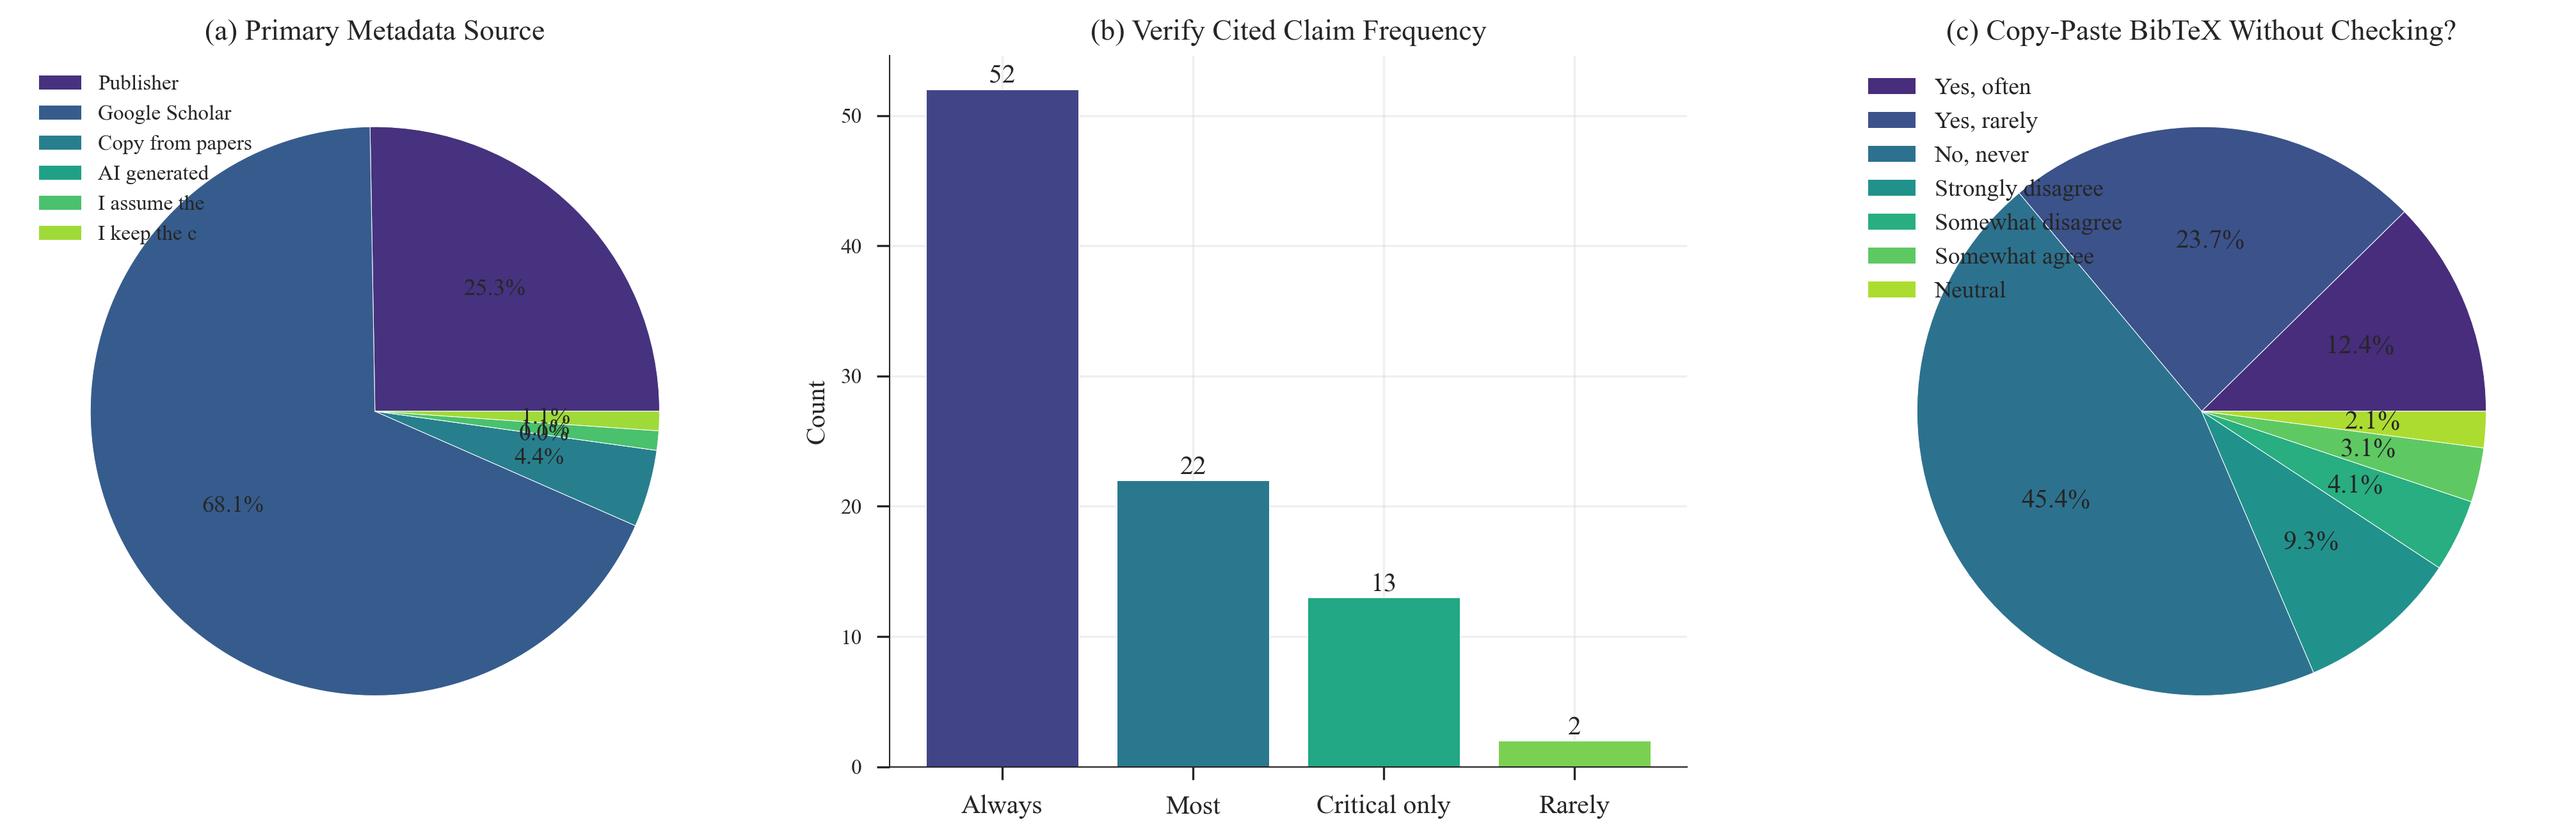

Saved: figs/citation_practices.pdf


In [132]:
# Figure 5: Citation Practices
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# (a) Metadata Source - use legend
ax = axes[0]
if 'metadata_source' in combined_stats:
    data = combined_stats['metadata_source']['counts']
    short_labels = {
        'Direct export from publisher': 'Publisher',
        'Google Scholar "Cite" button': 'Google Scholar',
        'Copy from other papers': 'Copy from papers',
        'AI-generated': 'AI generated',
    }
    data_short = {}
    for k, v in data.items():
        for sk, sv in short_labels.items():
            if sk.lower() in k.lower() or k.lower() in sk.lower():
                data_short[sv] = v
                break
        else:
            data_short[k[:12]] = v
    colors = sns.color_palette("viridis", len(data_short))
    wedges, texts, autotexts = ax.pie(data_short.values(), autopct='%1.1f%%', colors=colors,
                                       textprops={'fontsize': 9}, pctdistance=0.6)
    ax.legend(wedges, data_short.keys(), loc='upper left', fontsize=8, frameon=False)
ax.set_title('(a) Primary Metadata Source', fontsize=11)

# (b) Verify Claim Frequency - shorter labels
ax = axes[1]
if 'verify_claim_freq' in combined_stats:
    data = combined_stats['verify_claim_freq']['counts']
    order_map = {'Every single time': 'Always', 'Most of the time': 'Most', 
                 'Only for critical claims': 'Critical only', 'Rarely': 'Rarely'}
    ordered = {}
    for o, short in order_map.items():
        for k, v in data.items():
            if o.lower() in k.lower() or k.lower() in o.lower():
                ordered[short] = v
                break
    colors = sns.color_palette("viridis", len(ordered))
    bars = ax.bar(range(len(ordered)), list(ordered.values()), color=colors)
    ax.set_xticks(range(len(ordered)))
    ax.set_xticklabels(list(ordered.keys()), rotation=0, ha='center', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('(b) Verify Cited Claim Frequency', fontsize=11)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{int(h)}', ha='center', fontsize=10)

# (c) Copy-paste BibTeX - use legend
ax = axes[2]
if 'copypaste_bibtex' in combined_stats:
    data = combined_stats['copypaste_bibtex']['counts']
    colors = sns.color_palette("viridis", len(data))
    wedges, texts, autotexts = ax.pie(data.values(), autopct='%1.1f%%', colors=colors,
                                       textprops={'fontsize': 10}, pctdistance=0.6)
    ax.legend(wedges, data.keys(), loc='upper left', fontsize=9, frameon=False)
ax.set_title('(c) Copy-Paste BibTeX Without Checking?', fontsize=11)

plt.tight_layout(pad=1.5)
plt.savefig('figs/citation_practices.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figs/citation_practices.pdf")

## 10. Reviewer Reactions

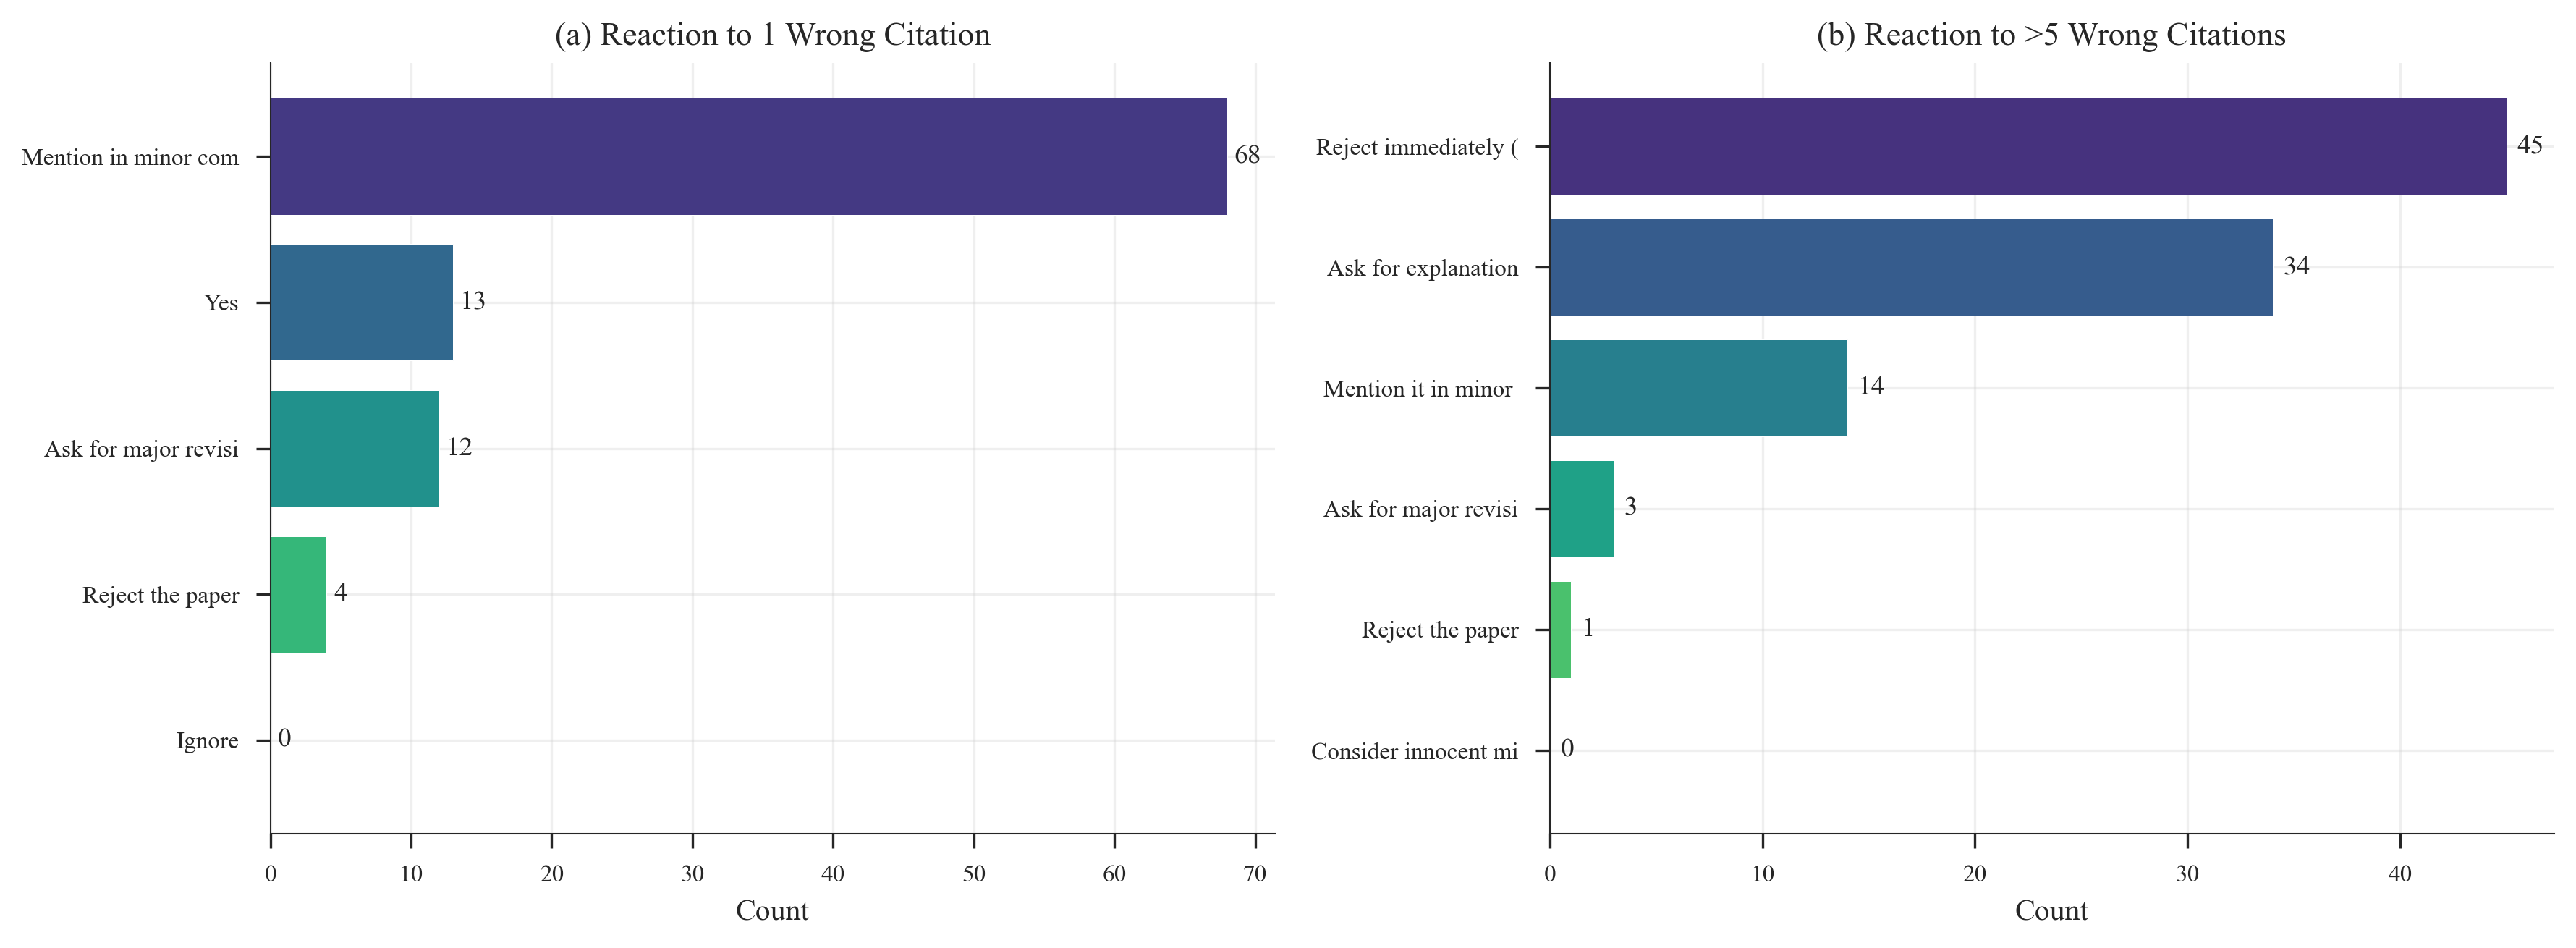

Saved: figs/reviewer_reactions.pdf


In [133]:
# Figure 6: Reviewer Reactions
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Reaction to One Error - shorter labels
ax = axes[0]
if 'reaction_one_error' in combined_stats:
    data = combined_stats['reaction_one_error']['counts']
    sorted_data = dict(sorted(data.items(), key=lambda x: -x[1]))
    short_data = {k[:20]: v for k, v in sorted_data.items()}
    colors = sns.color_palette("viridis", len(short_data))
    bars = ax.barh(list(short_data.keys()), list(short_data.values()), color=colors)
    ax.set_xlabel('Count', fontsize=10)
    ax.set_title('(a) Reaction to 1 Wrong Citation', fontsize=11)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, short_data.values()):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

# (b) Reaction to Multiple Errors - shorter labels
ax = axes[1]
if 'reaction_multiple_errors' in combined_stats:
    data = combined_stats['reaction_multiple_errors']['counts']
    sorted_data = dict(sorted(data.items(), key=lambda x: -x[1]))
    short_data = {k[:20]: v for k, v in sorted_data.items()}
    colors = sns.color_palette("viridis", len(short_data))
    bars = ax.barh(list(short_data.keys()), list(short_data.values()), color=colors)
    ax.set_xlabel('Count', fontsize=10)
    ax.set_title('(b) Reaction to >5 Wrong Citations', fontsize=11)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, short_data.values()):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

plt.tight_layout(pad=1.5)
plt.savefig('figs/reviewer_reactions.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figs/reviewer_reactions.pdf")

## 11. Key Findings Summary

In [134]:
# Calculate key statistics
n_cn = 79
n_en = 18
n_total = n_cn + n_en

print("=" * 70)
print("KEY FINDINGS: Academic Writing, AI Tools & Citation Integrity Survey")
print("=" * 70)
print(f"\nTotal Respondents: {n_total} (Chinese: {n_cn}, English: {n_en})")

# 1. AI Adoption
ai_data = combined_stats.get('use_ai_tools', {}).get('counts', {})
ai_yes = sum(v for k, v in ai_data.items() if 'yes' in k.lower() or '是' in k)
print(f"\n1. AI TOOL ADOPTION")
print(f"   • {ai_yes}/{n_total} ({ai_yes/n_total*100:.1f}%) use AI-powered tools for research")

# 2. Hallucination Experience
hall_data = combined_stats.get('hallucination_freq', {}).get('counts', {})
hall_often = sum(v for k, v in hall_data.items() if 'often' in k.lower() or '>50' in k or '20-50' in k or '经常' in k or '非常频繁' in k)
hall_total = sum(hall_data.values())
print(f"\n2. HALLUCINATION EXPERIENCE")
print(f"   • {hall_often}/{hall_total} ({hall_often/hall_total*100:.1f}%) encounter hallucinations often (>20%)")

# 3. Verification
verify_data = combined_stats.get('verify_ai_ref', {}).get('counts', {})
verify_always = sum(v for k, v in verify_data.items() if '100%' in k or 'always' in k.lower())
verify_total = sum(verify_data.values())
print(f"\n3. VERIFICATION BEHAVIOR")
print(f"   • {verify_always}/{verify_total} ({verify_always/verify_total*100:.1f}%) always verify AI-provided references")

# 4. Severity
sev_data = combined_stats.get('severity', {}).get('counts', {})
crisis = sum(v for k, v in sev_data.items() if 'crisis' in k.lower() or '严重危机' in k)
major = sum(v for k, v in sev_data.items() if 'major' in k.lower() or '主要问题' in k)
print(f"\n4. ISSUE SEVERITY PERCEPTION")
print(f"   • Critical crisis: {crisis} ({crisis/n_total*100:.1f}%)")
print(f"   • Major problem: {major} ({major/n_total*100:.1f}%)")
print(f"   • Total severe: {crisis+major} ({(crisis+major)/n_total*100:.1f}%)")

# 5. Automated Tools
auto_data = combined_stats.get('automated_tools', {}).get('counts', {})
auto_yes = sum(v for k, v in auto_data.items() if 'yes' in k.lower() or 'absolutely' in k.lower() or '是，绝对' in k)
print(f"\n5. SUPPORT FOR AUTOMATED TOOLS")
print(f"   • {auto_yes}/{n_total} ({auto_yes/n_total*100:.1f}%) strongly support automated DOI/reference checking")

# 6. Responsibility
resp_data = combined_stats.get('responsibility', {}).get('counts', {})
authors = sum(v for k, v in resp_data.items() if 'author' in k.lower() or '作者' in k)
print(f"\n6. RESPONSIBILITY")
print(f"   • {authors}/{n_total} ({authors/n_total*100:.1f}%) believe AUTHORS are primarily responsible")

# 7. Risky Behaviors
bibtex_data = combined_stats.get('copypaste_bibtex', {}).get('counts', {})
bibtex_yes = sum(v for k, v in bibtex_data.items() if 'yes' in k.lower() or '是' in k)
print(f"\n7. RISKY CITATION BEHAVIORS")
print(f"   • {bibtex_yes}/{n_total} ({bibtex_yes/n_total*100:.1f}%) have copy-pasted BibTeX without checking")

print("\n" + "=" * 70)

KEY FINDINGS: Academic Writing, AI Tools & Citation Integrity Survey

Total Respondents: 97 (Chinese: 79, English: 18)

1. AI TOOL ADOPTION
   • 74/97 (76.3%) use AI-powered tools for research

2. HALLUCINATION EXPERIENCE
   • 34/83 (41.0%) encounter hallucinations often (>20%)

3. VERIFICATION BEHAVIOR
   • 64/82 (78.0%) always verify AI-provided references

4. ISSUE SEVERITY PERCEPTION
   • Critical crisis: 34 (35.1%)
   • Major problem: 24 (24.7%)
   • Total severe: 58 (59.8%)

5. SUPPORT FOR AUTOMATED TOOLS
   • 50/97 (51.5%) strongly support automated DOI/reference checking

6. RESPONSIBILITY
   • 71/97 (73.2%) believe AUTHORS are primarily responsible

7. RISKY CITATION BEHAVIORS
   • 35/97 (36.1%) have copy-pasted BibTeX without checking



In [135]:
# Export summary statistics to CSV
summary_rows = []

for name, data in combined_stats.items():
    for option, count in data['counts'].items():
        summary_rows.append({
            'Question': name,
            'Option': option,
            'Count': count,
            'Percentage': f"{count/n_total*100:.1f}%"
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('survey_combined_statistics.csv', index=False)
print(f"Saved combined statistics to: survey_combined_statistics.csv")
print(f"Total rows: {len(summary_df)}")

Saved combined statistics to: survey_combined_statistics.csv
Total rows: 243


In [136]:
# List all generated figures
import glob

figs = sorted(glob.glob('figs/*.pdf'))
print(f"\nGenerated {len(figs)} figures:")
for f in figs:
    print(f"  • {f}")


Generated 10 figures:
  • figs\ai_tool_usage.pdf
  • figs\citation_practices.pdf
  • figs\demo_papers.pdf
  • figs\demo_position.pdf
  • figs\demo_research_area.pdf
  • figs\demo_reviewer.pdf
  • figs\hallucination_verification.pdf
  • figs\reviewer_reactions.pdf
  • figs\severity_responsibility.pdf
  • figs\survey_dashboard.pdf


## 12. Combined Dashboard Figure

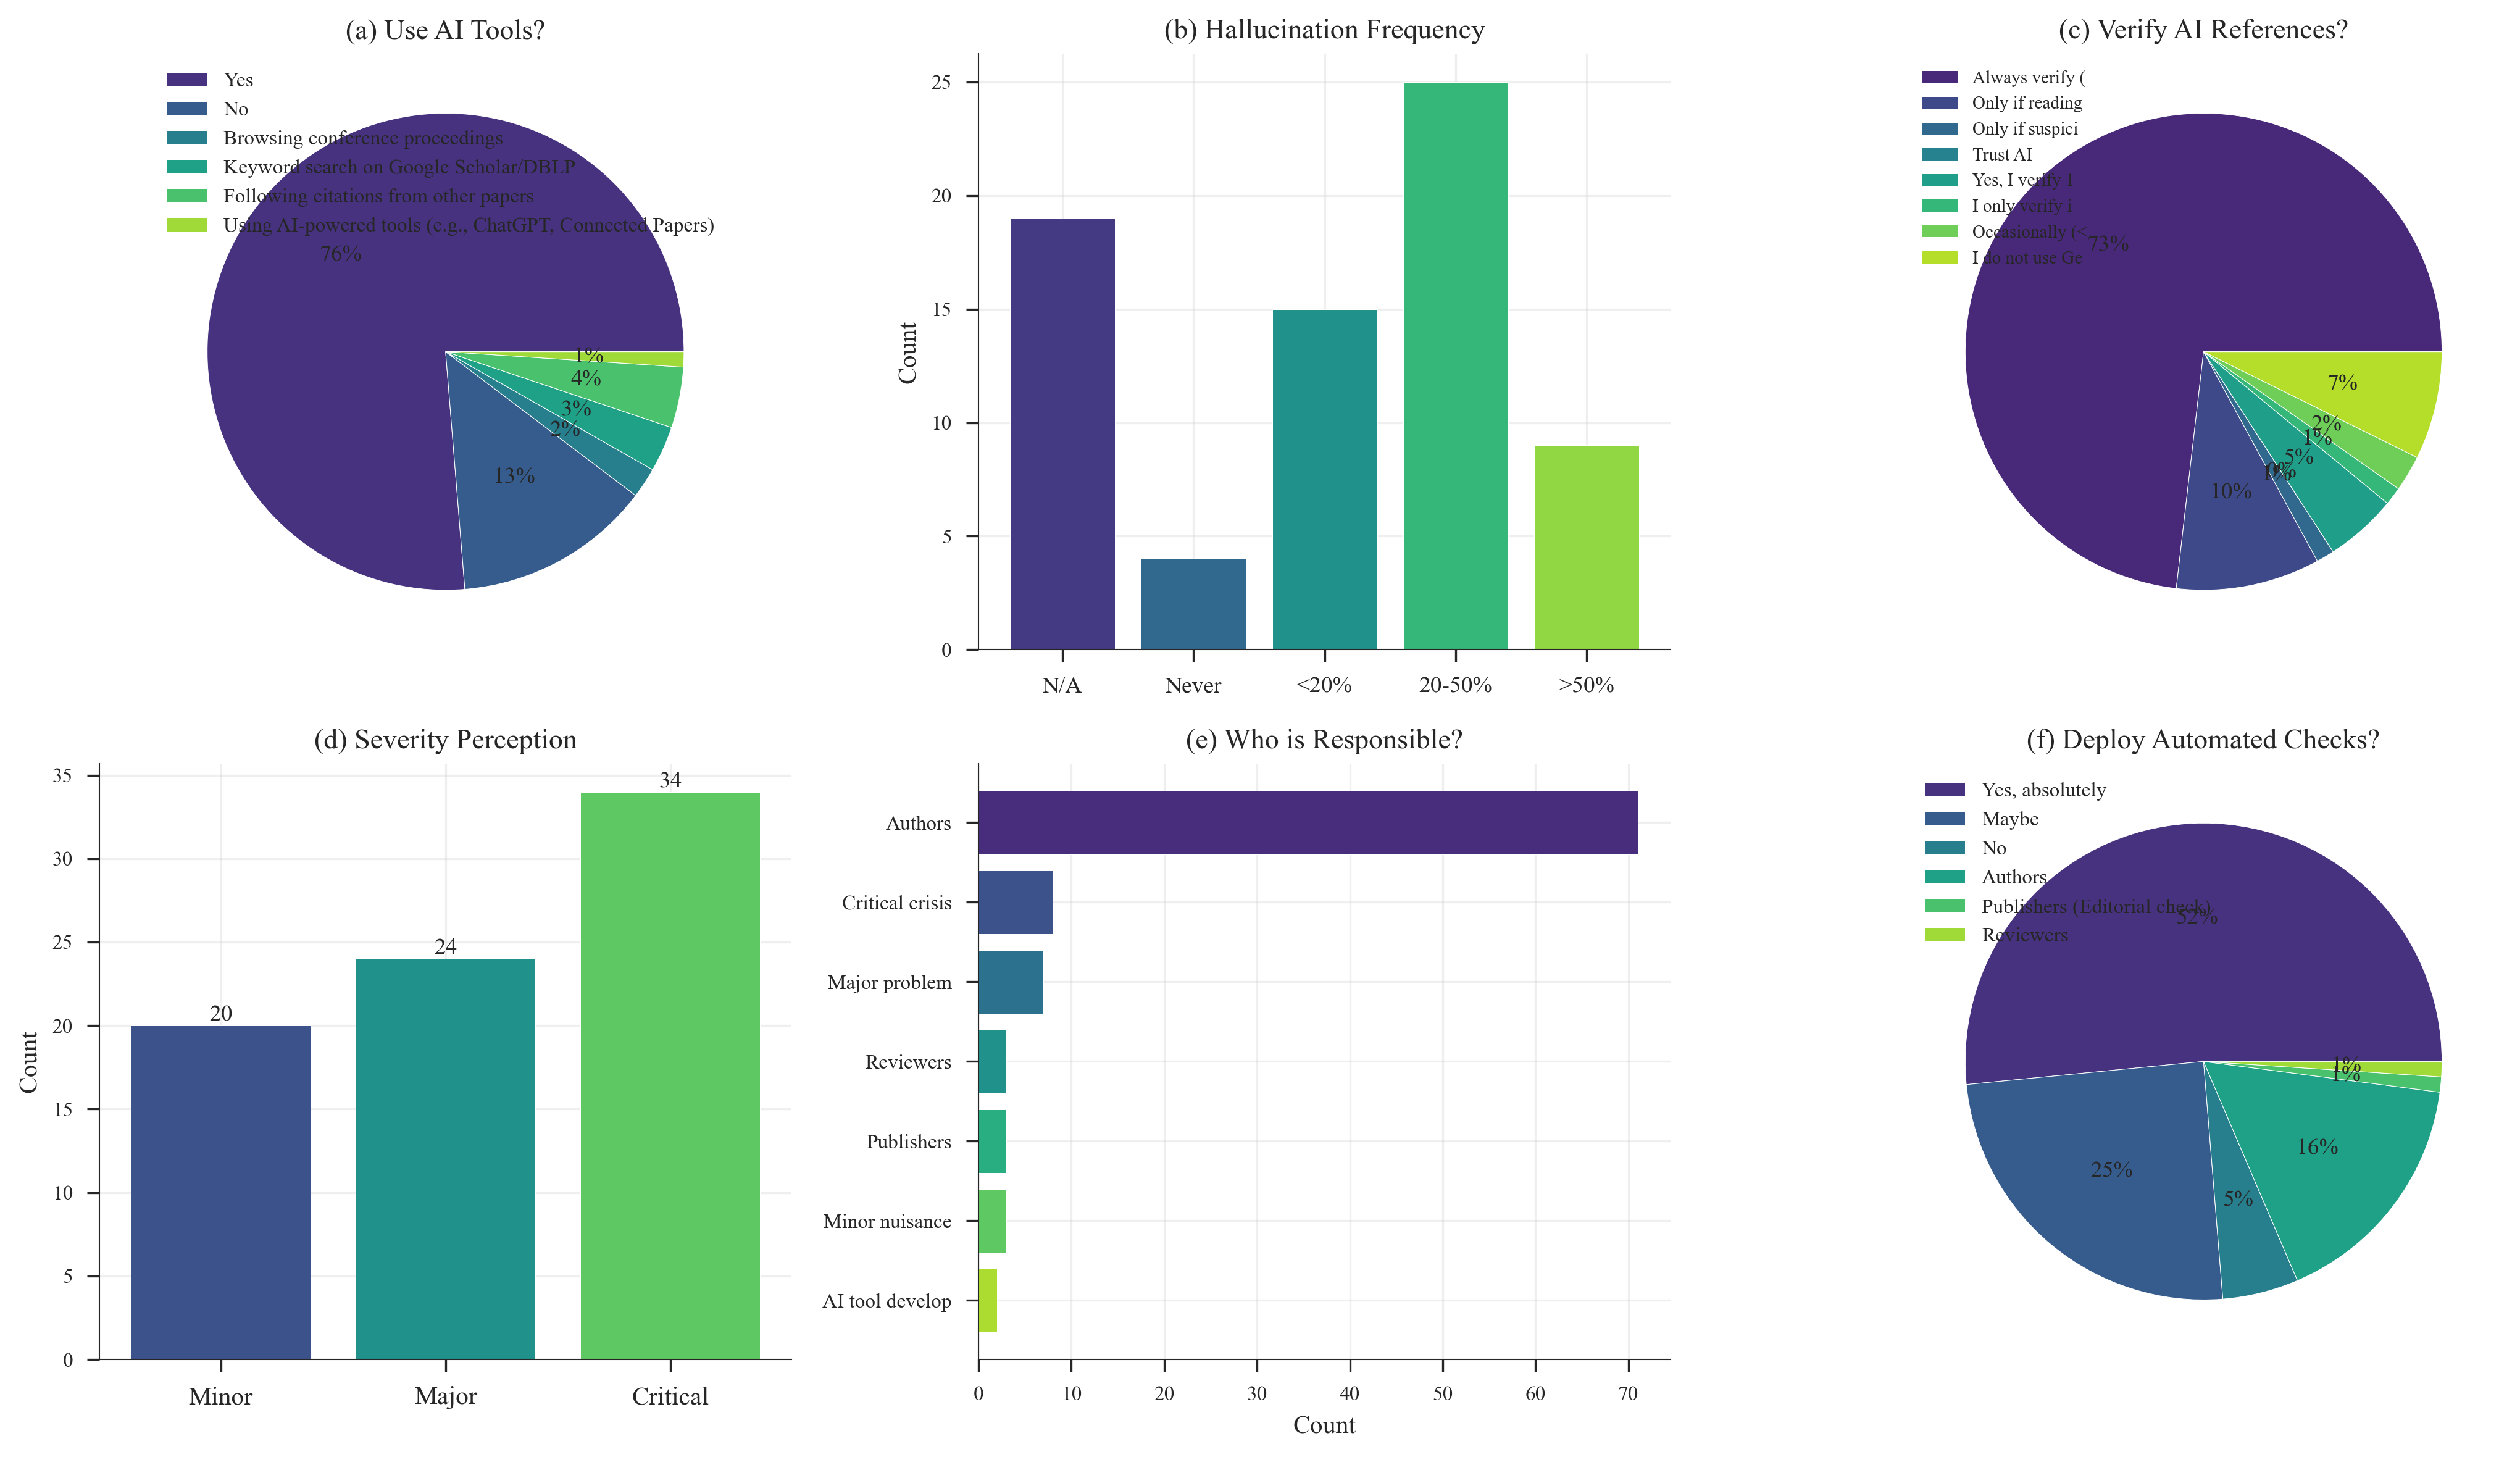

Saved: figs/survey_dashboard.pdf


In [137]:
# Figure 7: Combined Dashboard (6-panel)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# (a) AI Tool Usage - use legend instead of labels on pie
ax = axes[0, 0]
data = combined_stats.get('use_ai_tools', {}).get('counts', {})
colors = sns.color_palette("viridis", len(data))
wedges, texts, autotexts = ax.pie(data.values(), autopct='%1.0f%%', colors=colors, 
                                   textprops={'fontsize': 9}, pctdistance=0.6)
ax.legend(wedges, data.keys(), loc='upper left', fontsize=8, frameon=False)
ax.set_title('(a) Use AI Tools?', fontsize=11)

# (b) Hallucination Frequency
ax = axes[0, 1]
data = combined_stats.get('hallucination_freq', {}).get('counts', {})
# Filter and order with shorter labels
order_map = {"Don't use LLMs": "N/A", 'Never': 'Never', 'Occasionally (<20%)': '<20%', 
             'Often (20-50%)': '20-50%', 'Very Often (>50%)': '>50%'}
ordered = {}
for o, short in order_map.items():
    for k, v in data.items():
        if o.lower()[:10] in k.lower() or k.lower()[:10] in o.lower():
            ordered[short] = ordered.get(short, 0) + v
colors = sns.color_palette("viridis", len(ordered))
bars = ax.bar(range(len(ordered)), list(ordered.values()), color=colors)
ax.set_xticks(range(len(ordered)))
ax.set_xticklabels(list(ordered.keys()), rotation=0, ha='center', fontsize=9)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('(b) Hallucination Frequency', fontsize=11)

# (c) Verification Behavior - use legend
ax = axes[0, 2]
data = combined_stats.get('verify_ai_ref', {}).get('counts', {})
colors = sns.color_palette("viridis", len(data))
short = {k[:15]: v for k, v in data.items()}
wedges, texts, autotexts = ax.pie(short.values(), autopct='%1.0f%%', colors=colors, 
                                   textprops={'fontsize': 9}, pctdistance=0.6)
ax.legend(wedges, short.keys(), loc='upper left', fontsize=7, frameon=False)
ax.set_title('(c) Verify AI References?', fontsize=11)

# (d) Severity
ax = axes[1, 0]
data = combined_stats.get('severity', {}).get('counts', {})
order = ['Minor', 'Major', 'Critical']
order_full = ['Minor nuisance', 'Major problem', 'Critical crisis']
ordered = {o: sum(v for k, v in data.items() if full.lower()[:8] in k.lower()) 
           for o, full in zip(order, order_full)}
colors = sns.color_palette("viridis", len(ordered))
bars = ax.bar(ordered.keys(), ordered.values(), color=colors)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('(d) Severity Perception', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{int(h)}', ha='center', va='bottom', fontsize=9)

# (e) Responsibility - shorter labels
ax = axes[1, 1]
data = combined_stats.get('responsibility', {}).get('counts', {})
sorted_data = dict(sorted(data.items(), key=lambda x: -x[1]))
# Shorten labels
short_labels = {k[:15]: v for k, v in sorted_data.items()}
colors = sns.color_palette("viridis", len(short_labels))
bars = ax.barh(list(short_labels.keys()), list(short_labels.values()), color=colors)
ax.set_xlabel('Count', fontsize=10)
ax.set_title('(e) Who is Responsible?', fontsize=11)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=8)

# (f) Automated Tools - use legend
ax = axes[1, 2]
data = combined_stats.get('automated_tools', {}).get('counts', {})
colors = sns.color_palette("viridis", len(data))
wedges, texts, autotexts = ax.pie(data.values(), autopct='%1.0f%%', colors=colors, 
                                   textprops={'fontsize': 9}, pctdistance=0.6)
ax.legend(wedges, data.keys(), loc='upper left', fontsize=8, frameon=False)
ax.set_title('(f) Deploy Automated Checks?', fontsize=11)

plt.tight_layout(pad=1.5)
plt.savefig('figs/survey_dashboard.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figs/survey_dashboard.pdf")

## 13. Export Results to Markdown Report

In [138]:
# Generate comprehensive Markdown report
from datetime import datetime
import glob

def generate_markdown_report():
    """Generate a comprehensive Markdown report of all survey findings."""
    
    n_cn = 79
    n_en = 18
    n_total = n_cn + n_en
    
    md_lines = []
    
    # Header
    md_lines.append("# Survey Analysis Report: Academic Writing, AI Tools & Citation Integrity")
    md_lines.append("")
    md_lines.append(f"**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    md_lines.append("")
    md_lines.append("---")
    md_lines.append("")
    
    # Executive Summary
    md_lines.append("## Executive Summary")
    md_lines.append("")
    md_lines.append(f"This report analyzes survey responses from **{n_total} researchers** across two surveys:")
    md_lines.append(f"- **Chinese Survey**: {n_cn} respondents (aggregated statistics)")
    md_lines.append(f"- **English Survey**: {n_en} respondents (individual responses)")
    md_lines.append("")
    
    # Key Findings
    md_lines.append("## Key Findings")
    md_lines.append("")
    
    # 1. AI Adoption
    ai_data = combined_stats.get('use_ai_tools', {}).get('counts', {})
    ai_yes = sum(v for k, v in ai_data.items() if 'yes' in k.lower() or '是' in k)
    md_lines.append("### 1. AI Tool Adoption")
    md_lines.append("")
    md_lines.append(f"- **{ai_yes}/{n_total} ({ai_yes/n_total*100:.1f}%)** of researchers use AI-powered tools for research")
    md_lines.append("")
    md_lines.append("| Response | Count | Percentage |")
    md_lines.append("|----------|-------|------------|")
    for opt, cnt in sorted(ai_data.items(), key=lambda x: -x[1]):
        md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
    md_lines.append("")
    
    # 2. Hallucination Experience
    hall_data = combined_stats.get('hallucination_freq', {}).get('counts', {})
    hall_often = sum(v for k, v in hall_data.items() if 'often' in k.lower() or '>50' in k or '20-50' in k or '经常' in k or '非常频繁' in k)
    hall_total = sum(hall_data.values())
    md_lines.append("### 2. Hallucination Experience")
    md_lines.append("")
    if hall_total > 0:
        md_lines.append(f"- Among LLM users, **{hall_often}/{hall_total} ({hall_often/hall_total*100:.1f}%)** experience hallucinated citations **often or very often**")
    md_lines.append("")
    md_lines.append("| Frequency | Count | Percentage |")
    md_lines.append("|-----------|-------|------------|")
    for opt, cnt in sorted(hall_data.items(), key=lambda x: -x[1]):
        md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
    md_lines.append("")
    
    # 3. Verification Behavior
    verify_data = combined_stats.get('verify_ai_ref', {}).get('counts', {})
    always_verify = sum(v for k, v in verify_data.items() if 'always' in k.lower() or '100%' in k or '总是' in k)
    md_lines.append("### 3. Verification Behavior")
    md_lines.append("")
    verify_total = sum(verify_data.values())
    if verify_total > 0:
        md_lines.append(f"- Only **{always_verify}/{verify_total} ({always_verify/verify_total*100:.1f}%)** always verify AI-generated references")
    md_lines.append("")
    md_lines.append("| Verification Approach | Count | Percentage |")
    md_lines.append("|----------------------|-------|------------|")
    for opt, cnt in sorted(verify_data.items(), key=lambda x: -x[1]):
        md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
    md_lines.append("")
    
    # 4. Severity Perception
    sev_data = combined_stats.get('severity', {}).get('counts', {})
    crisis = sum(v for k, v in sev_data.items() if 'crisis' in k.lower() or '严重危机' in k)
    major = sum(v for k, v in sev_data.items() if 'major' in k.lower() or '主要问题' in k)
    md_lines.append("### 4. Issue Severity Perception")
    md_lines.append("")
    md_lines.append(f"- **{crisis+major}/{n_total} ({(crisis+major)/n_total*100:.1f}%)** consider hallucinated citations a **major problem or critical crisis**")
    md_lines.append(f"  - Critical crisis: {crisis} ({crisis/n_total*100:.1f}%)")
    md_lines.append(f"  - Major problem: {major} ({major/n_total*100:.1f}%)")
    md_lines.append("")
    md_lines.append("| Severity Level | Count | Percentage |")
    md_lines.append("|----------------|-------|------------|")
    for opt, cnt in sorted(sev_data.items(), key=lambda x: -x[1]):
        md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
    md_lines.append("")
    
    # 5. Responsibility
    resp_data = combined_stats.get('responsibility', {}).get('counts', {})
    authors = sum(v for k, v in resp_data.items() if 'author' in k.lower() or '作者' in k)
    md_lines.append("### 5. Responsibility Attribution")
    md_lines.append("")
    md_lines.append(f"- **{authors}/{n_total} ({authors/n_total*100:.1f}%)** believe **authors** are primarily responsible for citation accuracy")
    md_lines.append("")
    md_lines.append("| Responsible Party | Count | Percentage |")
    md_lines.append("|-------------------|-------|------------|")
    for opt, cnt in sorted(resp_data.items(), key=lambda x: -x[1]):
        md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
    md_lines.append("")
    
    # 6. Automated Tools Support
    auto_data = combined_stats.get('automated_tools', {}).get('counts', {})
    auto_yes = sum(v for k, v in auto_data.items() if 'yes' in k.lower() or 'absolutely' in k.lower() or '是，绝对' in k)
    md_lines.append("### 6. Support for Automated Tools")
    md_lines.append("")
    md_lines.append(f"- **{auto_yes}/{n_total} ({auto_yes/n_total*100:.1f}%)** strongly support automated DOI/reference checking in submission systems")
    md_lines.append("")
    md_lines.append("| Response | Count | Percentage |")
    md_lines.append("|----------|-------|------------|")
    for opt, cnt in sorted(auto_data.items(), key=lambda x: -x[1]):
        md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
    md_lines.append("")
    
    # 7. Risky Behaviors
    bibtex_data = combined_stats.get('copypaste_bibtex', {}).get('counts', {})
    bibtex_yes = sum(v for k, v in bibtex_data.items() if 'yes' in k.lower() or '是' in k)
    md_lines.append("### 7. Risky Citation Behaviors")
    md_lines.append("")
    md_lines.append(f"- **{bibtex_yes}/{n_total} ({bibtex_yes/n_total*100:.1f}%)** have copy-pasted BibTeX entries without verification")
    md_lines.append("")
    
    cite_data = combined_stats.get('cite_without_reading', {}).get('counts', {})
    cite_yes = sum(v for k, v in cite_data.items() if 'yes' in k.lower() or '是' in k)
    if cite_data:
        md_lines.append(f"- **{cite_yes}/{n_total} ({cite_yes/n_total*100:.1f}%)** have cited AI-suggested papers without reading them")
    md_lines.append("")
    
    # Demographics Section
    md_lines.append("---")
    md_lines.append("")
    md_lines.append("## Detailed Results")
    md_lines.append("")
    
    # Demographics
    md_lines.append("### Demographics")
    md_lines.append("")
    
    # Position
    pos_data = combined_stats.get('position', {}).get('counts', {})
    if pos_data:
        md_lines.append("#### Academic Position")
        md_lines.append("")
        md_lines.append("| Position | Count | Percentage |")
        md_lines.append("|----------|-------|------------|")
        for opt, cnt in sorted(pos_data.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # Research Area
    area_data = combined_stats.get('research_area', {}).get('counts', {})
    if area_data:
        md_lines.append("#### Research Area")
        md_lines.append("")
        md_lines.append("| Area | Count | Percentage |")
        md_lines.append("|------|-------|------------|")
        for opt, cnt in sorted(area_data.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # Publication Experience
    pub_data = combined_stats.get('papers_published', {}).get('counts', {})
    if pub_data:
        md_lines.append("#### Publication Experience")
        md_lines.append("")
        md_lines.append("| Papers Published | Count | Percentage |")
        md_lines.append("|------------------|-------|------------|")
        order = ['0', '1-5', '6-10', '11-20', '20+']
        for opt in order:
            if opt in pub_data:
                cnt = pub_data[opt]
                md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # Reviewer Status
    rev_data = combined_stats.get('is_reviewer', {}).get('counts', {})
    if rev_data:
        md_lines.append("#### Reviewer Experience")
        md_lines.append("")
        md_lines.append("| Served as Top-Tier Reviewer | Count | Percentage |")
        md_lines.append("|-----------------------------|-------|------------|")
        for opt, cnt in sorted(rev_data.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # AI Usage Details
    md_lines.append("### AI Tool Usage Details")
    md_lines.append("")
    
    # AI for Text Polishing
    polish_data = combined_stats.get('ai_text_polish', {}).get('counts', {})
    if polish_data:
        md_lines.append("#### AI for Text Polishing")
        md_lines.append("")
        md_lines.append("| Usage Pattern | Count | Percentage |")
        md_lines.append("|---------------|-------|------------|")
        for opt, cnt in sorted(polish_data.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # AI for Citations
    cite_usage = combined_stats.get('ai_citation_usage', {}).get('counts', {})
    if cite_usage:
        md_lines.append("#### AI for Citation Tasks")
        md_lines.append("")
        md_lines.append("| Task | Count | Percentage |")
        md_lines.append("|------|-------|------------|")
        for opt, cnt in sorted(cite_usage.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # Citation Practices
    md_lines.append("### Citation Practices")
    md_lines.append("")
    
    # Metadata Source
    meta_data = combined_stats.get('metadata_source', {}).get('counts', {})
    if meta_data:
        md_lines.append("#### Primary Metadata Source")
        md_lines.append("")
        md_lines.append("| Source | Count | Percentage |")
        md_lines.append("|--------|-------|------------|")
        for opt, cnt in sorted(meta_data.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # Verify Claim Frequency
    claim_data = combined_stats.get('verify_claim_freq', {}).get('counts', {})
    if claim_data:
        md_lines.append("#### Claim Verification Frequency")
        md_lines.append("")
        md_lines.append("| Frequency | Count | Percentage |")
        md_lines.append("|-----------|-------|------------|")
        for opt, cnt in sorted(claim_data.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # Reviewer Reactions
    md_lines.append("### Reviewer Reactions to Citation Errors")
    md_lines.append("")
    
    # Reaction to one error
    one_err = combined_stats.get('reaction_one_error', {}).get('counts', {})
    if one_err:
        md_lines.append("#### Reaction to 1 Wrong Citation")
        md_lines.append("")
        md_lines.append("| Reaction | Count | Percentage |")
        md_lines.append("|----------|-------|------------|")
        for opt, cnt in sorted(one_err.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # Reaction to multiple errors
    multi_err = combined_stats.get('reaction_multiple_errors', {}).get('counts', {})
    if multi_err:
        md_lines.append("#### Reaction to >5 Wrong Citations")
        md_lines.append("")
        md_lines.append("| Reaction | Count | Percentage |")
        md_lines.append("|----------|-------|------------|")
        for opt, cnt in sorted(multi_err.items(), key=lambda x: -x[1]):
            md_lines.append(f"| {opt} | {cnt} | {cnt/n_total*100:.1f}% |")
        md_lines.append("")
    
    # Generated Figures
    md_lines.append("---")
    md_lines.append("")
    md_lines.append("## Generated Figures")
    md_lines.append("")
    figs = sorted(glob.glob('figs/*.pdf'))
    md_lines.append(f"A total of **{len(figs)} figures** were generated:")
    md_lines.append("")
    for f in figs:
        fig_name = os.path.basename(f).replace('.pdf', '').replace('_', ' ').title()
        md_lines.append(f"- `{f}`: {fig_name}")
    md_lines.append("")
    
    # Footer
    md_lines.append("---")
    md_lines.append("")
    md_lines.append("*This report was automatically generated from survey analysis.*")
    
    return '\n'.join(md_lines)

# Generate and save the report
report = generate_markdown_report()
with open('survey_analysis_report.md', 'w', encoding='utf-8') as f:
    f.write(report)

print("=" * 70)
print("Markdown report saved to: survey_analysis_report.md")
print("=" * 70)
print("\nReport preview (first 100 lines):")
print("-" * 70)
for line in report.split('\n')[:100]:
    print(line)

Markdown report saved to: survey_analysis_report.md

Report preview (first 100 lines):
----------------------------------------------------------------------
# Survey Analysis Report: Academic Writing, AI Tools & Citation Integrity

**Generated**: 2026-02-01 16:14

---

## Executive Summary

This report analyzes survey responses from **97 researchers** across two surveys:
- **Chinese Survey**: 79 respondents (aggregated statistics)
- **English Survey**: 18 respondents (individual responses)

## Key Findings

### 1. AI Tool Adoption

- **74/97 (76.3%)** of researchers use AI-powered tools for research

| Response | Count | Percentage |
|----------|-------|------------|
| Yes | 74 | 76.3% |
| No | 13 | 13.4% |
| Following citations from other papers | 4 | 4.1% |
| Keyword search on Google Scholar/DBLP | 3 | 3.1% |
| Browsing conference proceedings | 2 | 2.1% |
| Using AI-powered tools (e.g., ChatGPT, Connected Papers) | 1 | 1.0% |

### 2. Hallucination Experience

- Among LLM users, **34